# Intro
The inspiration was the Kalmogorov-Arnold Theorem, which is:

$f(x_{1}, x_{2}, ..., x_{n}) = \sum_{q=1}^{2n+1} \phi_{q}(\sum_{q=1}^{n} \phi_{q,p}(x_{p})) $

It states every multivariate continuous function can be represented as a superposition of continuous single-variable functions


# Kalmogorov-Arnold Network
The main goal is to simplify functions, but not the exact form, but a close approximation that gives some numbers called the Knot Vector. Each edge contains a learnable spline function defined by control points (knots) that determine its shape. These knot vectors are trained in the Kolmogorov-Arnold Network using gradient descent, allowing the network to learn optimal function shapes that best fit the data. During training, the spline parameters adjust to minimize loss, effectively learning the underlying mathematical relationships in the data.

# Comparison with MLP
$output = f(x_{1}) + f(x_{2}) $

whereas in MLP, the activation function isn't trainable:

$output = \delta(w_{1}x_{1} + w_{2}x_{2}) $

In KANs, each $f $ is a learnable spline function that can adapt its shape during training. The network learns how much each input contributes (as weights do in MLPs) and the actual functional transformation to apply to each input - it means KANs can capture non-linear relationships directly in the edge functions rather than relying on fixed activations and linear combinations.


# Implementation
KANs are implemented using B-splines, which are smooth piecewise polynomial functions. Each spline is defined by a set of control points and basis functions. During forward propagation, input values are passed through these learned spline functions on the edges, and nodes simply sum the results. Backpropagation updates the spline coefficients by computing gradients with respect to the loss function.

Modern implementations, like pykan (showed below), provide efficient gradient computation for spline parameters and include visualization tools to inspect learned functions. The training process typically involves grid refinement, where the resolution of splines increases as training progresses to capture finer details of the target function.

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 5.08e-04 | test_loss: 4.82e-04 | reg: 1.78e+01 | : 100%|█| 1000/1000 [01:21<00:00, 12.


saving model version 0.1
saving model version 0.2
([0], [x_1, x_2])


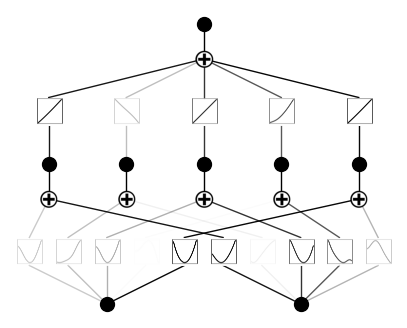

In [ ]:
import torch
import numpy as np
from kan import KAN

# f(x1, x2) = x1^2 + x2^2
X = np.random.uniform(-2, 2, (600, 2))
y = (X[:, 0]**2 + X[:, 1]**2).reshape(-1, 1)

X = torch.FloatTensor(X)
y = torch.FloatTensor(y)

X_train, X_test = X[:500], X[500:]
y_train, y_test = y[:500], y[500:]

# 2 inputs, 5 hidden layers, 1 output
model = KAN(width=[2, 5, 1])

dataset = {
    'train_input': X_train, 
    'train_label': y_train,
    'test_input': X_test,
    'test_label': y_test
}
model.fit(dataset, steps=1000)

model.plot()
model.prune()
formula = model.symbolic_formula()
print(formula)

In [8]:
from impl.newkan import NewKAN

model = NewKAN([2, 5, 1], grid_size=5, spline_order=3)

X = np.random.uniform(-1, 1, (100, 2))
y_true = X[:, 0]**2 + X[:, 1]**2

y_pred = model(X)

print(f"Input shape: {X.shape}")
print(f"Output shape: {y_pred.shape}")
print(f"Sample predictions: {y_pred[:5].flatten()}")
print(f"Sample true values: {y_true[:5]}")

Input shape: (100, 2)
Output shape: (100, 1)
Sample predictions: [0.21523905 0.12703699 0.12873742 0.13157348 0.17433492]
Sample true values: [1.55127241 0.91106407 1.41632529 0.07138468 1.34477099]
